In [2]:
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import colors
import numpy as np
import os,re
import math

In [3]:
# import plotting packages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

from mpl_toolkits.mplot3d import Axes3D # 3d plot
from matplotlib import cm #color map
from matplotlib.ticker import FormatStrFormatter # set decimals in ticks
from matplotlib import rc,re
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator

font=12
fontfml='Times New Roman'
plt.rcParams['font.size'] = font
plt.rcParams['font.family'] = fontfml
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm'] =fontfml
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
#plt.legend(loc="best",ncol=1,columnspacing=0.5,handlelength=1,handletextpad=0.3)

from LBL_funcs_fullSpectrum import *
from LBL_funcs_plotting import *
from LBL_funcs_inclined import *

In [4]:
file_dir = "/mnt/dengnan/RTM/fullspectrum/HG/"
Fls = ['Results_case2_AOD=0.1243_COD=0_kap=[10, 11, 12]_th0=18_Ta=297_RH=0.43.npy']

In [5]:
results = np.load(file_dir +'/'+Fls[0],  allow_pickle=True).item()
dnu = 3# speactral resolution 0.1 is enough, 0.01 is too fine, especially for cloudy periods
nu=np.arange(2500,35000,dnu) 
F_uw = results.get('F_uw')
np.trapz(F_uw,nu)

202.4425076825995

In [6]:
results.keys()

dict_keys(['F_dw', 'F_uw', 'F_dni', 'F_dhi'])

# broadband, COD, theta, 

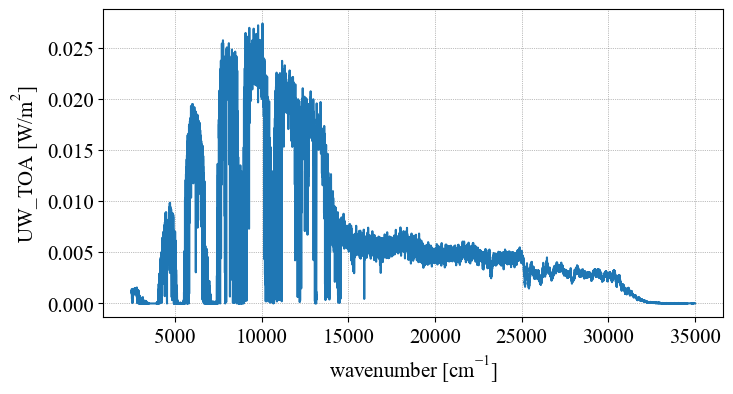

In [7]:
font=15
fontfml='Times New Roman'
plt.rcParams['font.size'] = font
plt.rcParams['font.family'] = fontfml
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm'] =fontfml
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.figure(figsize=(8, 4))
gs1 = gridspec.GridSpec(1, 1) 
gs1.update(wspace=0.07, hspace=0.10)
axs = fig.add_subplot(gs1[0])
GHI = []

axs.plot(nu,F_uw)
#axs.set_title('$T_s$ = 290 K')
axs.set_xlabel(r"wavenumber [cm$^{-1}$]")

axs.set_ylabel(r"UW_TOA [W/m$^2$]")
axs.grid(color='grey', linestyle=':', linewidth=0.5)
fig_dir = "./"
# Uncomment the next line to save the figure
#fig.savefig(fig_dir + 'Zenith_COD_UW_toa.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from fun_nearealtime_RTM import FY4A_calinu,get_calibration_srf

In [9]:
data = np.genfromtxt('./data/profiles/ASTMG173.csv', delimiter=',', skip_header=2,  # in wavenumber basis
                     names=['wavelength', 'extraterrestrial', '37tilt', 'direct_circum'])
ref_lam = data['wavelength']  # nm avoid hearder 1
ref_E = data['extraterrestrial']
ref_E_nu = -ref_E * ref_lam ** 2 / 1e7  # W/[m2*nm-1] tp W/[m2*cm-1]
F_dw_os = -np.interp(-nu, -1e7 / ref_lam, ref_E_nu)  # W/[m2*cm-1] to W/cm-1

In [70]:
F_dw_os_srf_channel = []
for channel in channels:
    # load calibration data : Spectral Response Func
    srf, nu_channel = get_calibration_srf(channel, file_dir)
    F_dw_os_channel = -np.interp(-nu_channel, -1e7 / ref_lam, ref_E_nu)  # W/[m2*cm-1] to W/cm-1
    #F_dw_os_SRF = np.multiply(F_dw_os_channel, srf)
    F_dw_os_srf_channel.append(np.trapz(F_dw_os_channel, nu_channel))
    # nu_idx = np.nonzero(np.isin(nu_channels, nu_channel))[0]  # fixed 1 April.
    
    # # correct uw
    # uw_cor = np.multiply(uw[nu_idx], srf)
    # uw_channel = np.trapz(uw_cor,nu_channel)
    # df.loc[0, channel] = uw_channel
F_dw_os_srf_channel

[323.0925977495013,
 847.5266602781963,
 449.98636612881165,
 62.198979454210104,
 74.51214842582357,
 118.66132238239614]

0.11135362687929827
0.1096368097639733
0.23101539749758876
0.0008276993348245741
0.262259576932115
0.1620263152580279


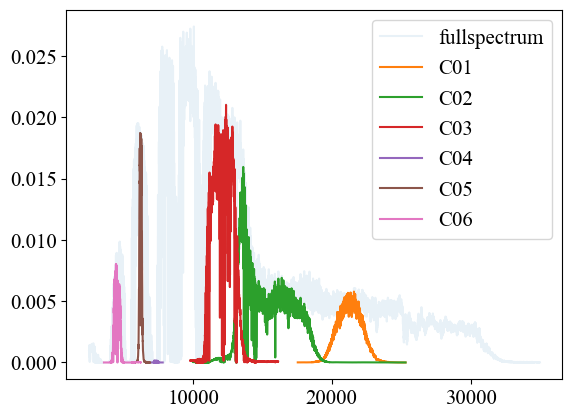

In [86]:
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
nu0 = np.arange(2500, 35000, 3)  # Wavenumber grid
nu_channels = FY4A_calinu(nu0, channels, "./FY4A_data/", dnu=3)
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                       12.06884597258561,13.936208329862962,18.20438461023419]
uw = F_uw
plt.plot(nu,F_uw, alpha=0.1, label='fullspectrum')
for i, channel in enumerate(channels):
    # load calibration data : Spectral Response Func
    srf, nu_channel = get_calibration_srf(channel, file_dir)
    nu_idx = np.nonzero(np.isin(nu0, nu_channel))[0]  # fixed 1 April.
    uw_cor = np.multiply(uw[nu_idx], srf)
    #uw_cor = uw[nu_idx]
    uw_channel = np.trapz(uw_cor, nu_channel)/F_dw_os_srf_channel[i]
    
    ref_channel = uw_channel#/np.pi
    #plt.plot(nu_channel,srf, label=f'{channel}')
    #plt.plot(nu_channel,uw[nu_idx], label=f'{channel}')
    plt.plot(nu_channel,uw_cor, label=f'{channel}')
    
    print(ref_channel)
    
plt.legend(loc ='upper right')
plt.show()